 # requirements

In [ ]:
import math
import itertools
import time
from datetime import timedelta, datetime
import numpy as np
import pandas as pd
#Graph
import seaborn  as sns
import matplotlib.pyplot as plt
# root path
import sys
import os

# Add the project root directory to sys.path
project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
sys.path.append(project_root)

# Now you can import from src
from src.app.utils import open_json

[nltk_data] Downloading package words to /home/usuario/nltk_data...
[nltk_data]   Package words is already up-to-date!


 # data

In [ ]:
df = pd.read_json('../data/data_jobs.json')
df

,vacancy_name,company,location,work_modality_english,seniority,link,job_function,industries,description,apply_link,publication_date,query_keyword,country,scraping_date
0,Machine Learning Engineer (Python) - Remote Work,BairesDev,Colombia,Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/machine-lear...,Information Technology,IT Services and IT Consulting,"At BairesDev®, we've been leading the way in t...",,2026-04-21,Machine Learning Consultant,colombia,2026-04-22
1,Machine Learning Engineer,Inetum,"Bogota, D.C., Capital District, Colombia",Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/machine-lear...,Consulting,IT Services and IT Consulting,Descripción de la empresa\n\nInetum es líder e...,,2026-04-21,Machine Learning Consultant,colombia,2026-04-22
2,Data Scientist (Python + AI) - Remote Work,BairesDev,Colombia,Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/data-scienti...,Information Technology,IT Services and IT Consulting,"At BairesDev®, we've been leading the way in t...",,2026-04-21,Machine Learning Consultant,colombia,2026-04-22
3,AI Engineer – Machine Learning & Generative AI...,Dixmasoft Technology,"Bogota, D.C., Capital District, Colombia",Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/ai-engineer-...,Information Technology,Information Technology & Services,Buscamos un(a) AI Engineer Junior y Semi Senio...,,2026-04-21,Machine Learning Consultant,colombia,2026-04-22
4,Sr. AI/ML Engineer,Perform,Colombia,Full-time,Not Applicable,https://co.linkedin.com/jobs/view/sr-ai-ml-eng...,Engineering and Information Technology,Information Technology & Services,About The Role\n\nWe are seeking a Senior AI/M...,,2026-04-21,Machine Learning Consultant,colombia,2026-04-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6075,"Senior Java Developer, Colombia",CI&T,"Medellin, Antioquia, Colombia",Full-time,Not Applicable,https://co.linkedin.com/jobs/view/senior-java-...,Engineering and Information Technology,IT Services and IT Consulting,"We are tech transformation specialists, unitin...",None,2026-04-22,proactive,Colombia,2026-04-22
6076,Virtual Receptionist (Construction),Emma of Torre.ai,Colombia,Full-time,Entry level,https://co.linkedin.com/jobs/view/virtual-rece...,Administrative,Staffing and Recruiting,I’m helping Your Startup Operations find a top...,None,2026-04-22,proactive,Colombia,2026-04-22
6077,Snr Account Manager,OLIVER | The Brandtech Group,Colombia,Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/snr-account-...,Sales and Business Development,"Technology, Information and Internet",Brandtech+ (formerly known as OLIVER+) is a gl...,None,2026-04-22,proactive,Colombia,2026-04-22
6078,Customer Success Manager,Door & Gate Domination,Colombia,Full-time,Mid-Senior level,https://co.linkedin.com/jobs/view/customer-suc...,None,Marketing Services,"About Us We’re Door & Gate Domination, a power...",None,2026-04-22,proactive,Colombia,2026-04-22


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6080 entries, 0 to 6079
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   vacancy_name           6080 non-null   object
 1   company                6080 non-null   object
 2   location               6080 non-null   object
 3   work_modality_english  6080 non-null   object
 4   seniority              6080 non-null   object
 5   link                   6080 non-null   object
 6   job_function           5911 non-null   object
 7   industries             6080 non-null   object
 8   description            6080 non-null   object
 9   apply_link             12 non-null     object
 10  publication_date       6080 non-null   object
 11  query_keyword          6080 non-null   object
 12  country                6080 non-null   object
 13  scraping_date          6080 non-null   object
dtypes: object(14)
memory usage: 712.5+ KB


In [ ]:
df_types = pd.DataFrame(df.dtypes)
object_features = df_types[df_types[0] == 'object'].index.to_list()
object_features

['vacancy_name',
 'company',
 'location',
 'work_modality_english',
 'seniority',
 'link',
 'job_function',
 'industries',
 'description',
 'apply_link',
 'publication_date',
 'query_keyword',
 'country',
 'scraping_date']

In [ ]:
float_features = df_types[df_types[0] == 'float64'].index.to_list()
float_features

[]

In [ ]:
int_features = df_types[df_types[0] == 'int64'].index.to_list()
int_features

[]

In [ ]:
bool_features = df_types[df_types[0] == 'bool'].index.to_list()
bool_features

[]

In [ ]:
df.describe().T

,count,unique,top,freq
vacancy_name,6080,302,Onboarding Manager - SaaS Startup,253
company,6080,178,BairesDev,534
location,6080,27,Colombia,3530
work_modality_english,6080,1,Full-time,6080
seniority,6080,7,Mid-Senior level,3837
link,6080,367,https://co.linkedin.com/jobs/view/operations-m...,94
job_function,5911,57,Information Technology,1224
industries,6080,86,IT Services and IT Consulting,1054
description,6080,311,"Hey! We’re Scale Up, and our client is looking...",253
apply_link,12,1,,12


In [ ]:
df[object_features].describe(include='all').T

,count,unique,top,freq
vacancy_name,6080,302,Onboarding Manager - SaaS Startup,253
company,6080,178,BairesDev,534
location,6080,27,Colombia,3530
work_modality_english,6080,1,Full-time,6080
seniority,6080,7,Mid-Senior level,3837
link,6080,367,https://co.linkedin.com/jobs/view/operations-m...,94
job_function,5911,57,Information Technology,1224
industries,6080,86,IT Services and IT Consulting,1054
description,6080,311,"Hey! We’re Scale Up, and our client is looking...",253
apply_link,12,1,,12


In [ ]:
for col in object_features:
    print(f'------>{col} : {df[col].unique()}')
    print(f'------>{col} : {df[col].value_counts(dropna=False)}')

------>vacancy_name : ['Machine Learning Engineer (Python) - Remote Work'
 'Machine Learning Engineer' 'Data Scientist (Python + AI) - Remote Work'
 'AI Engineer – Machine Learning & Generative AI Bogotá'
 'Sr. AI/ML Engineer' 'Senior ML Engineer - Remote Work'
 'Senior Machine Learning + LLM Engineer - Remote Work'
 'Ingeniero Mecánico para planta en Facatativá' 'Piping Engineer'
 'Piping Senior - Experience in construction'
 'Ingeniero Mecánico Líder Técnico – Diseño, Producción y Proyectos Industriales'
 'Inside Sales Representative' 'Operations Manager - 1258 -  Colombia'
 'Senior Software Engineering Manager'
 'Lead Front-End Engineer - Digital agency - (Colombia)'
 'Marketing Expert / Digital Growth Manager (B2B)' 'Recruiter'
 'Desarrollador Python Junior - Trabajo Remoto'
 'Senior Quality Automation Engineer (Selenium + Java + Python + AI)'
 'Jefe de ventas' 'Account Manager' 'Data Engineer - Remote Work'
 'Business Development Associate'
 'Digital Merchandiser | Freelance | Spa

 ## null values visualization

Text(50.722222222222214, 0.5, 'Fila')

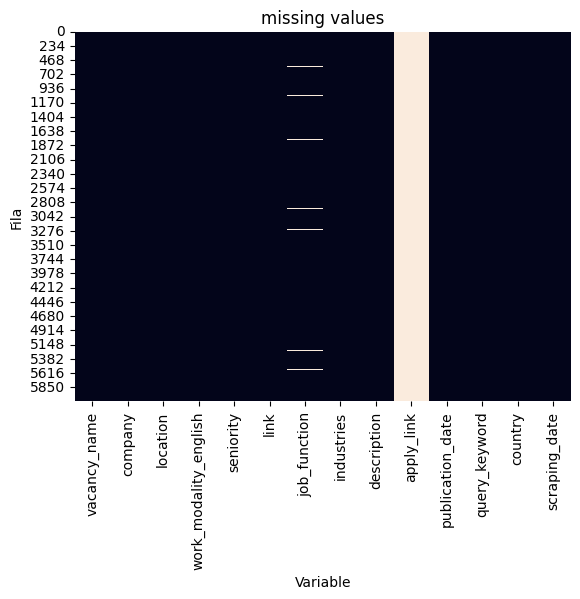

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("missing values")
plt.xlabel('Variable')
plt.ylabel('Fila')

 # categorical variables

Text(0.5, 1.0, "'industries'")

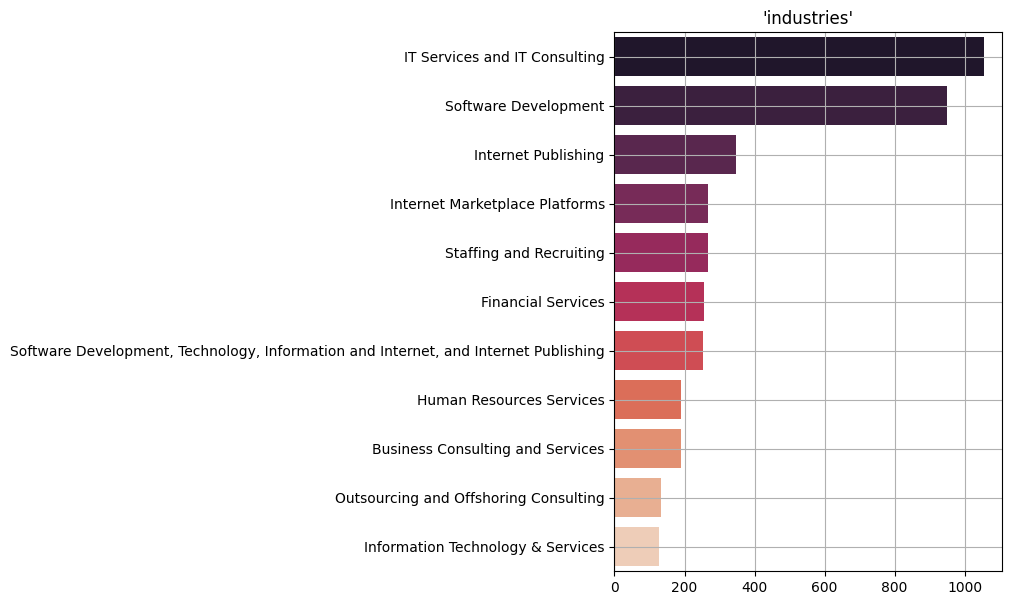

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['industries'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'industries'")

Text(0.5, 1.0, "'company'")

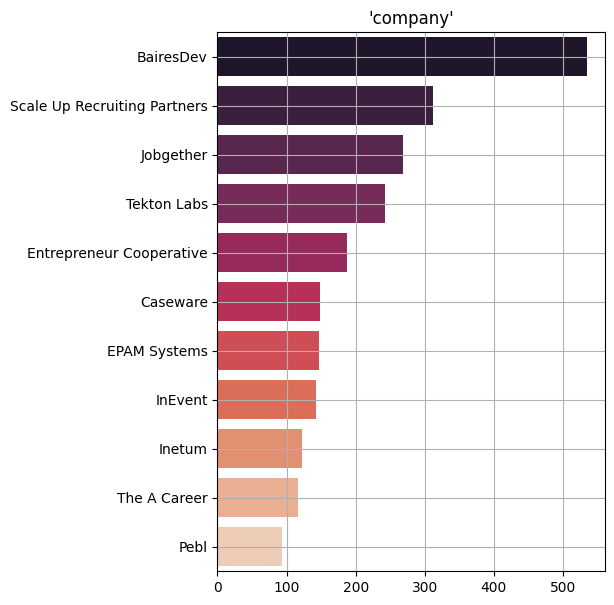

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['company'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'company'")

Text(0.5, 1.0, "'location'")

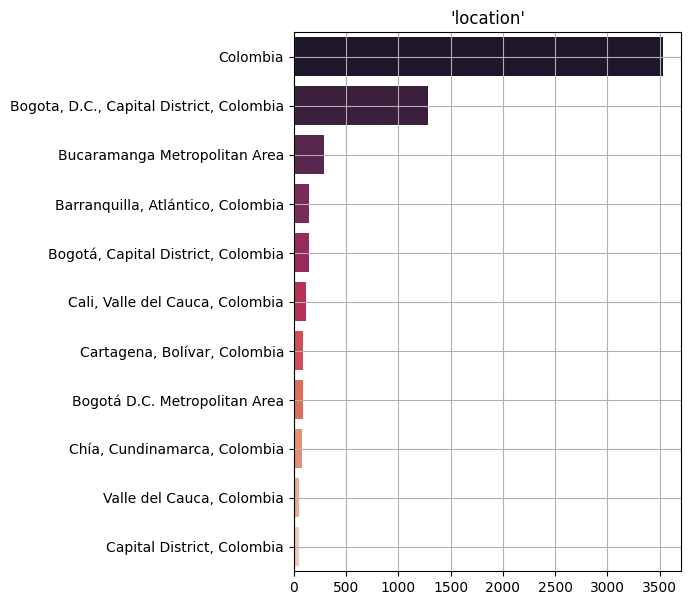

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['location'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'location'")

Text(0.5, 1.0, "'work_modality_english'")

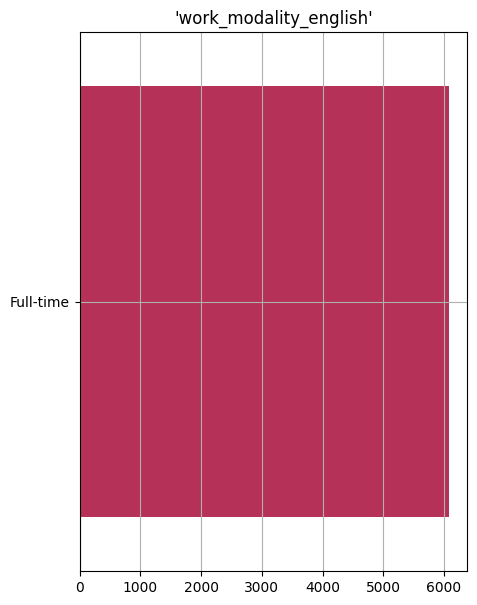

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['work_modality_english'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'work_modality_english'")

Text(0.5, 1.0, "'seniority'")

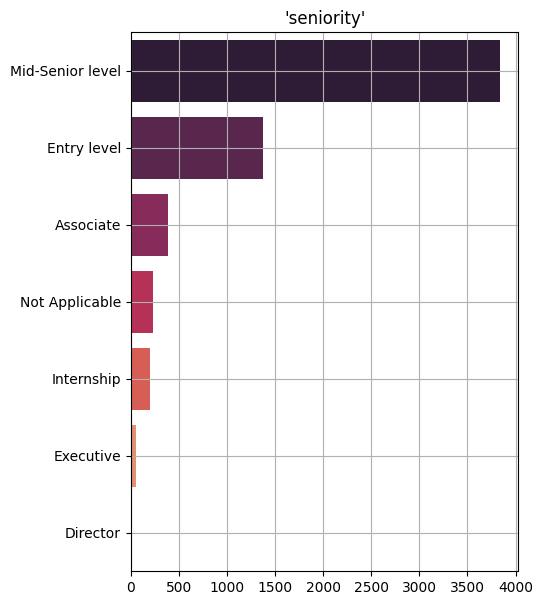

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['seniority'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'seniority'")

Text(0.5, 1.0, "'publication_date'")

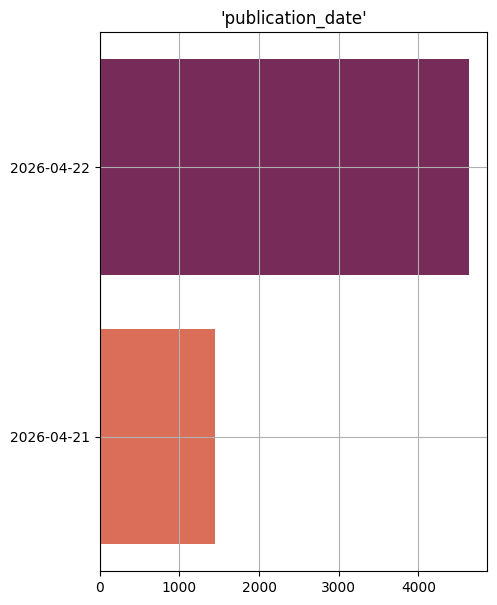

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df['publication_date'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'publication_date'")

 # knowledge based filters

In [ ]:
job_seeker = open_json('../data/job_seekers.json')
job_seeker[0].keys()
seniority_criteria = job_seeker[0]['seniority']
location_criteria = job_seeker[0]['location']
work_modality_criteria = job_seeker[0]['work_modality_english']
excluded_companies = ["BairesDev"]

In [ ]:
df_filtered = df[
    (df["seniority"].isin(seniority_criteria)) &  # Filter by seniority
    (df["location"].isin(location_criteria)) &    # Filter by location
    (df["work_modality_english"].isin(work_modality_criteria)) &  # Filter by work modality
    (~df["company"].isin(excluded_companies))     # Exclude specified companies
].copy()
df_filtered.shape

(3115, 14)

 # categorical variables

Text(0.5, 1.0, "'company'")

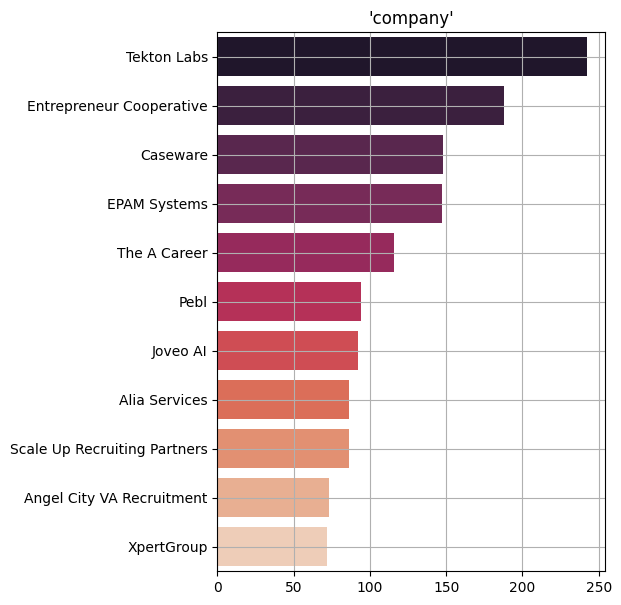

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df_filtered['company'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'company'")

Text(0.5, 1.0, "'location'")

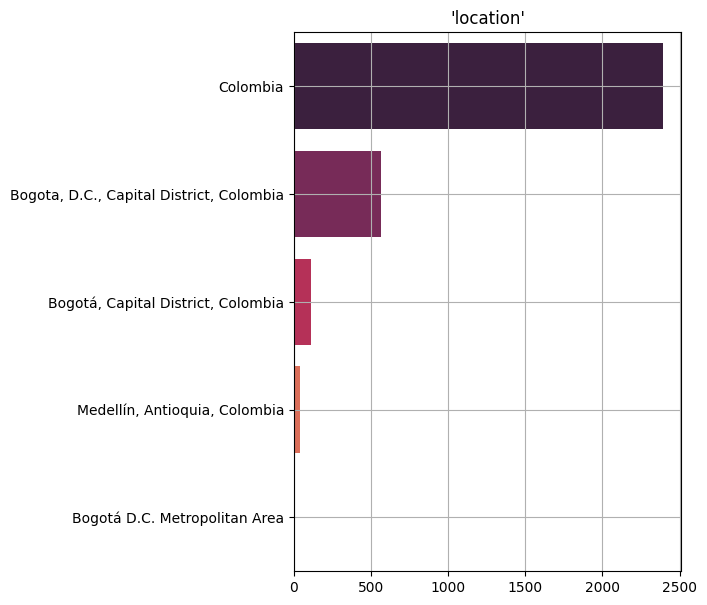

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df_filtered['location'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'location'")

Text(0.5, 1.0, "'work_modality_english'")

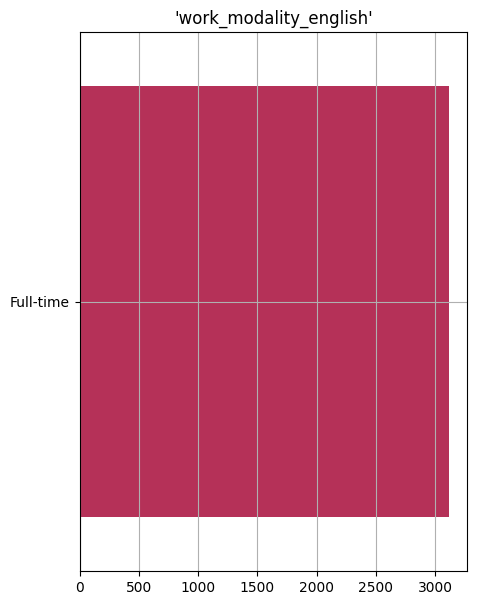

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df_filtered['work_modality_english'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'work_modality_english'")

Text(0.5, 1.0, "'seniority'")

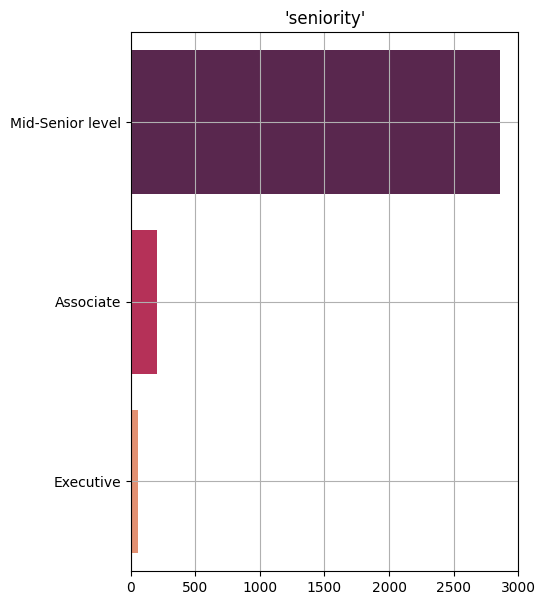

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df_filtered['seniority'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'seniority'")

Text(0.5, 1.0, "'publication_date'")

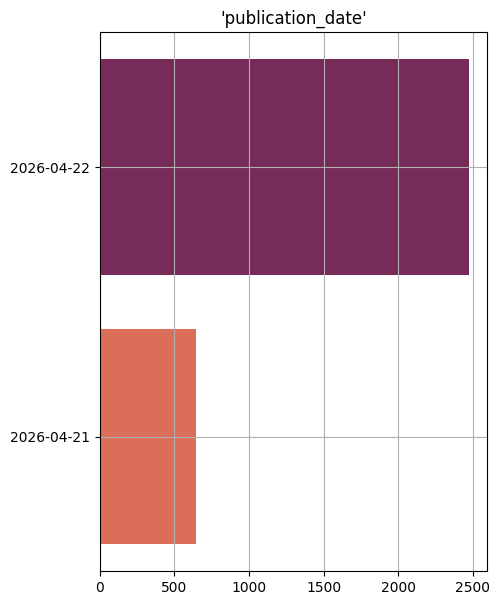

In [ ]:
plt.figure(figsize=(5,7))
a = pd.DataFrame(df_filtered['publication_date'].value_counts()[:11])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'publication_date'")

Text(0.5, 1.0, "'vacancy_name'")

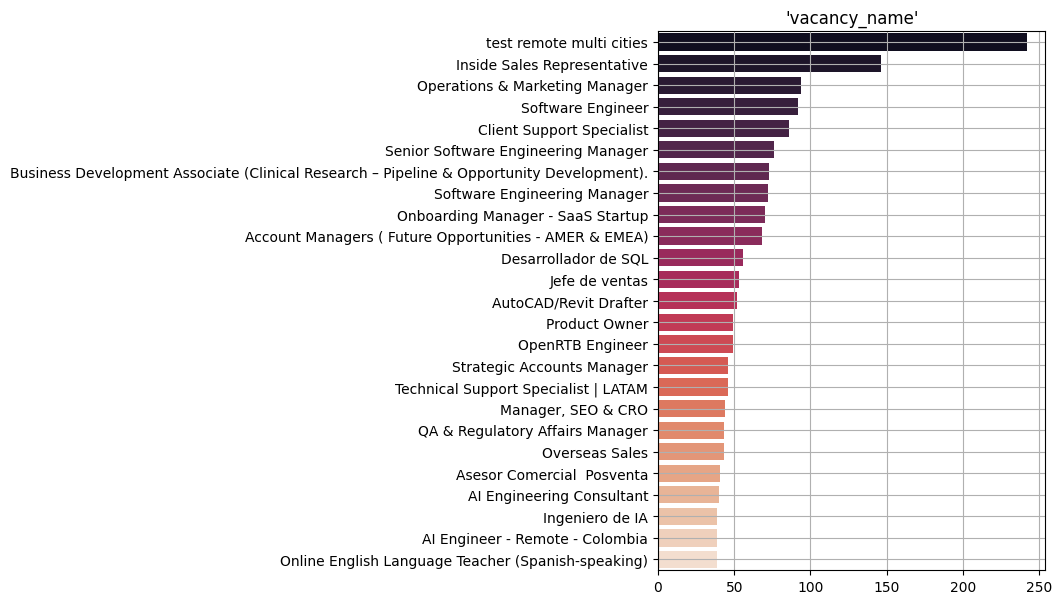

In [ ]:
plt.figure(figsize=(5,7))
df = df_filtered[df_filtered['publication_date'] > (datetime.now() - timedelta(days=3)).strftime('%Y-%m-%d')]
a = pd.DataFrame(df['vacancy_name'].value_counts()[:25])
y = np.array(list(a.index))
x = np.array(list(a['count']))
sns.barplot(x=x, y=y, palette="rocket", hue=y, legend=False)
plt.grid(True)
plt.title("'vacancy_name'")

 # skills

In [ ]:
df_skills = pd.read_json('../data/general_skills.json')
print(df_skills.shape)
df_skills['skills'] = df_skills['skills'].apply(lambda x: x.lower())
df_skills.drop_duplicates(inplace=True)
print(df_skills.shape)
df_skills.to_json('../data/general_skills.json')

(462, 1)
(462, 1)


 # Job title description file

In [ ]:
industries = [
    'IT Services and IT Consulting',
    'Software Development',
    'Technology, Information and Internet',
    'Business Consulting and Services'
]
df_summary = df_filtered[df_filtered['industries'].isin(industries)][['vacancy_name','description']][:1000].copy()
print(df_summary.shape)
df_summary.to_json('../data/vacancy_name_description.json')

(959, 2)
